# Flight Price Prediction

## Problem Statement

Flight ticket prices can be difficult to predict because prices may change over time.
This project aims to analyze flight fare data using Exploratory Data Analysis (EDA)
and develop Machine Learning models to predict flight ticket prices.

The project includes:
- Data Analysis and Exploratory Data Analysis
- Data Cleaning and Preprocessing
- Feature Engineering
- Machine Learning Model Development
- Comparison of Multiple Models
- Model Evaluation
- Production Model Selection
- Challenges Faced and Solutions

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:

# Loading the flight fare dataset

df = pd.read_excel("Flight_Fare.xlsx")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (10683, 11)


In [3]:
# Display first 5 rows

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']


In [5]:
# Check data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [7]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 220


In [8]:
# Display duplicate rows if any

df[df.duplicated()].head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303


In [9]:
# Check unique values in each column

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Airline: 12 unique values
Date_of_Journey: 44 unique values
Source: 5 unique values
Destination: 6 unique values
Route: 128 unique values
Dep_Time: 222 unique values
Arrival_Time: 1343 unique values
Duration: 368 unique values
Total_Stops: 5 unique values
Additional_Info: 10 unique values
Price: 1870 unique values


In [10]:
# Statistical summary of numerical columns

df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [11]:
# Display unique values for important categorical columns

categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Total_Stops",
    "Additional_Info"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print(df[column].value_counts())


Airline
Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Source
Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

Destination
Destination
Cochin       4537
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

Total_Stops
Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

Additional_Info
Additional_Info

In [12]:
# Display rows containing missing values

df[df.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [13]:
# Basic information about the target variable

print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Mean Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())
print("Standard Deviation:", df["Price"].std())

Minimum Price: 1759
Maximum Price: 79512
Mean Price: 9087.064120565385
Median Price: 8372.0
Standard Deviation: 4611.35916681709


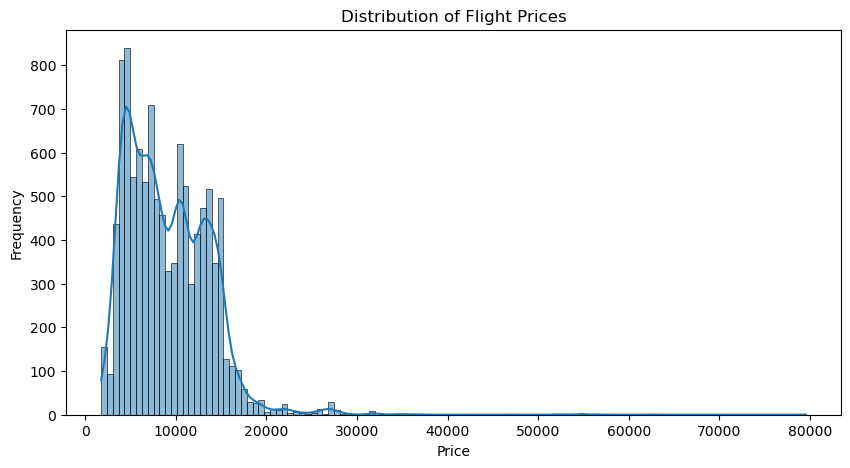

In [14]:
# Check the distribution of flight prices

plt.figure(figsize=(10, 5))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## Exploratory Data Analysis





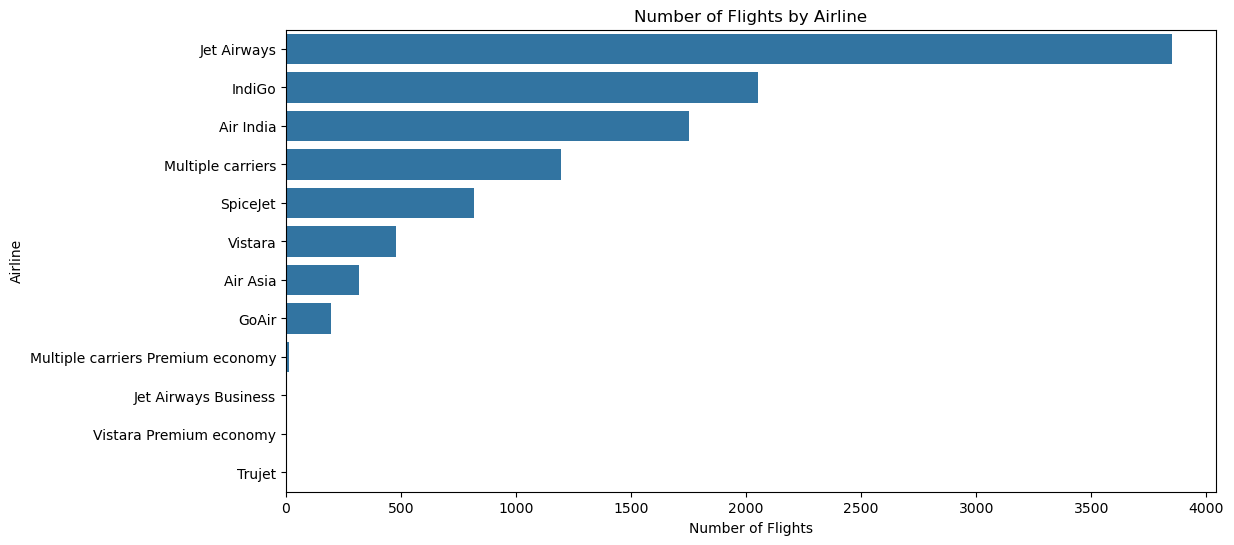

In [15]:
# Air line Distribution
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="Airline",
    order=df["Airline"].value_counts().index
)

plt.title("Number of Flights by Airline")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

plt.show()

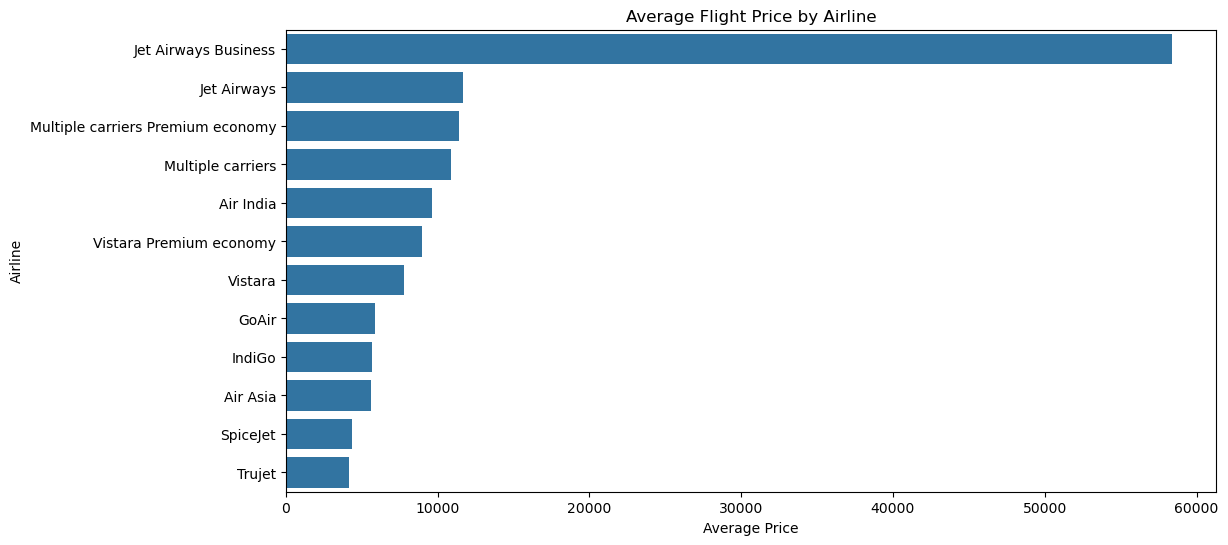

In [16]:
# Average price by airline
airline_price = (
    df.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=airline_price.values,
    y=airline_price.index
)

plt.title("Average Flight Price by Airline")
plt.xlabel("Average Price")
plt.ylabel("Airline")

plt.show()

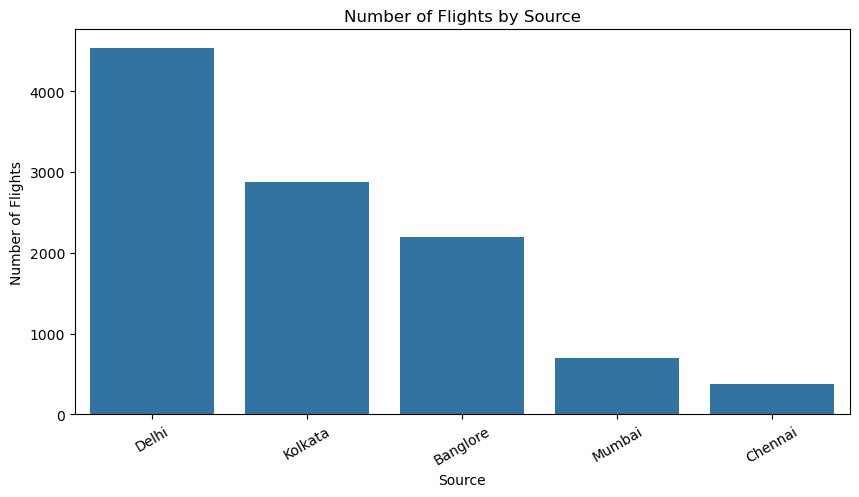

In [17]:
# Source Distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Source",
    order=df["Source"].value_counts().index
)

plt.title("Number of Flights by Source")
plt.xlabel("Source")
plt.ylabel("Number of Flights")

plt.xticks(rotation=30)

plt.show()

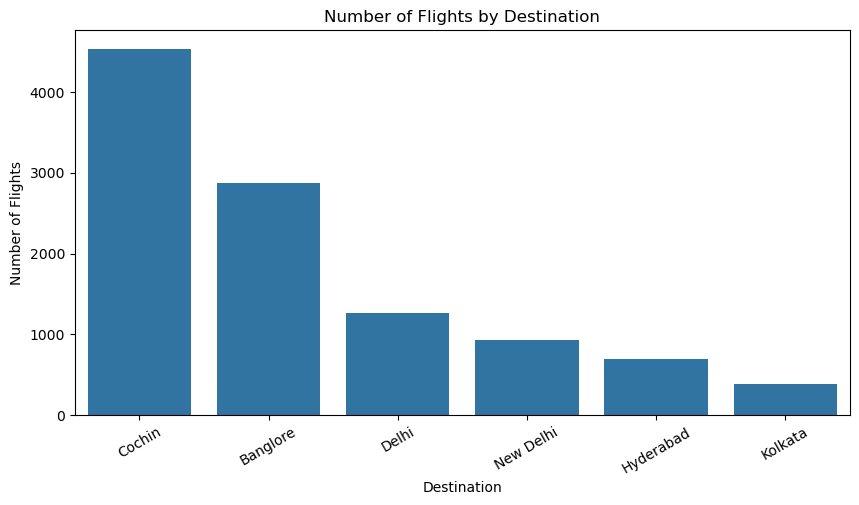

In [18]:
# Destination Distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Destination",
    order=df["Destination"].value_counts().index
)

plt.title("Number of Flights by Destination")
plt.xlabel("Destination")
plt.ylabel("Number of Flights")

plt.xticks(rotation=30)

plt.show()

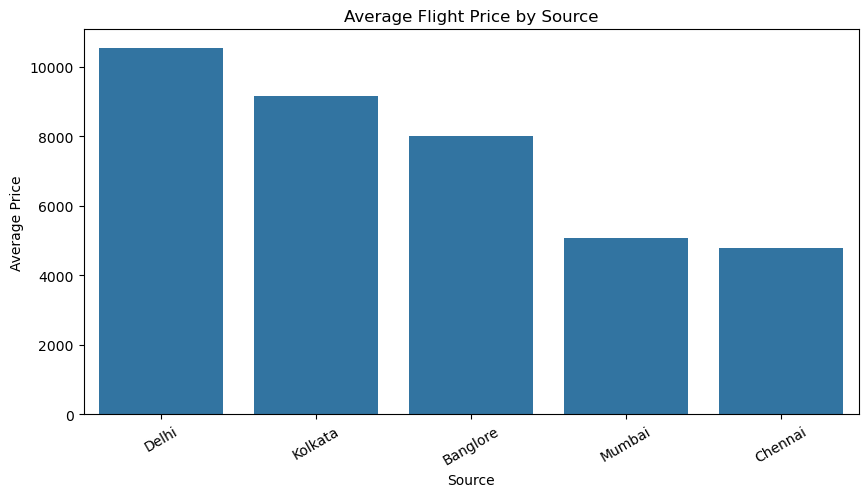

In [19]:
# Average price by source
source_price = (
    df.groupby("Source")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=source_price.index,
    y=source_price.values
)

plt.title("Average Flight Price by Source")
plt.xlabel("Source")
plt.ylabel("Average Price")

plt.xticks(rotation=30)

plt.show()

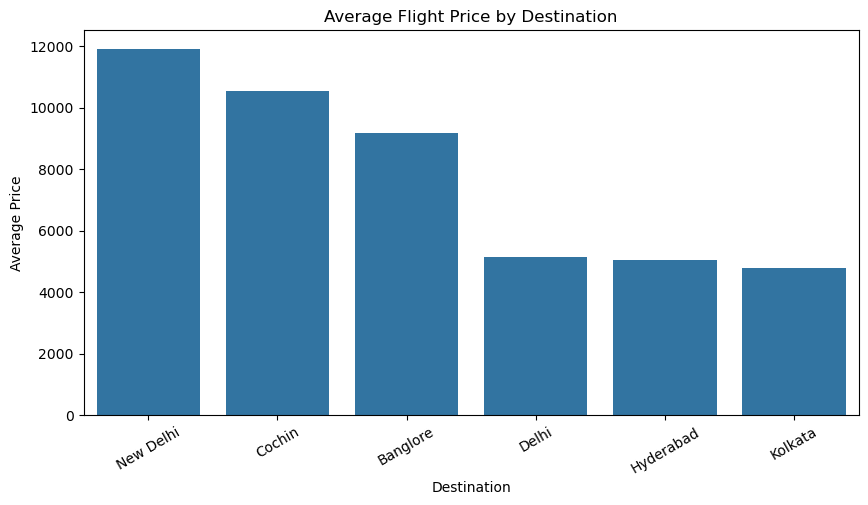

In [20]:
# Average price by Destination 
destination_price = (
    df.groupby("Destination")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=destination_price.index,
    y=destination_price.values
)

plt.title("Average Flight Price by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Price")

plt.xticks(rotation=30)

plt.show()

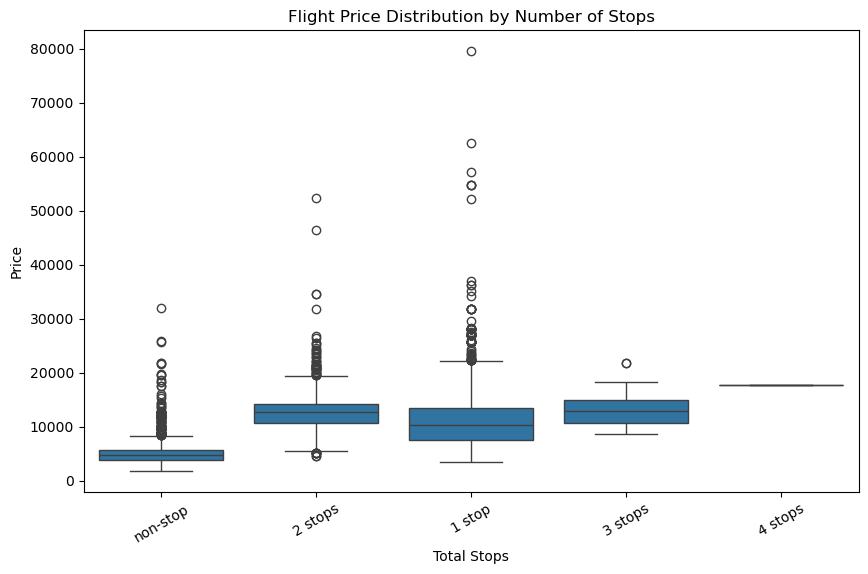

In [21]:
# Number of stops vs price
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.title("Flight Price Distribution by Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Price")

plt.xticks(rotation=30)

plt.show()

## Data Cleaning and Preprocessing



In [22]:
# Create a copy of the original dataset

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (10683, 11)
Working dataset shape: (10683, 11)


In [23]:
# Display rows containing missing values

missing_rows = df_clean[df_clean.isnull().any(axis=1)]

missing_rows

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [24]:
# Display the columns containing missing values

print("Missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values:
Route          1
Total_Stops    1
dtype: int64


In [25]:
# Remove duplicate records

before_duplicates = df_clean.shape[0]

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after_duplicates = df_clean.shape[0]

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 10683
Rows after removing duplicates: 10463
Duplicates removed: 220


In [26]:
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [27]:
# Display the incomplete records clearly

pd.set_option("display.max_columns", None)

df_clean[df_clean.isnull().any(axis=1)].T

,8893
Airline,Air India
Date_of_Journey,6/05/2019
Source,Delhi
Destination,Cochin
Route,NaN
Dep_Time,09:45
Arrival_Time,09:25 07 May
Duration,23h 40m
Total_Stops,NaN
Additional_Info,No info


In [28]:
# Confirm missing values after duplicate removal

print("Missing values after duplicate removal:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after duplicate removal:
Route          1
Total_Stops    1
dtype: int64


### Handling Missing Values



In [29]:
# Remove the record with missing values

before_missing = df_clean.shape[0]

df_clean = df_clean.dropna().reset_index(drop=True)

after_missing = df_clean.shape[0]

print("Rows before removing missing-value records:", before_missing)
print("Rows after removing missing-value records:", after_missing)
print("Rows removed:", before_missing - after_missing)

Rows before removing missing-value records: 10463
Rows after removing missing-value records: 10462
Rows removed: 1


In [30]:
print("Remaining missing values:")
print(df_clean.isnull().sum().sum())

Remaining missing values:
0


In [31]:
print("Final cleaned dataset shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing values:", df_clean.isnull().sum().sum())

Final cleaned dataset shape: (10462, 11)
Duplicate rows: 0
Missing values: 0


# Feature Engineering

In [32]:
df_clean["Date_of_Journey"].head()

0    24/03/2019
1     1/05/2019
2     9/06/2019
3    12/05/2019
4    01/03/2019
Name: Date_of_Journey, dtype: object

In [33]:
# Convert Date_of_Journey into day, month and year

df_clean["Journey_Day"] = pd.to_datetime(
    df_clean["Date_of_Journey"],
    dayfirst=True
).dt.day

df_clean["Journey_Month"] = pd.to_datetime(
    df_clean["Date_of_Journey"],
    dayfirst=True
).dt.month

df_clean["Journey_Year"] = pd.to_datetime(
    df_clean["Date_of_Journey"],
    dayfirst=True
).dt.year

In [34]:
df_clean[
    ["Date_of_Journey", "Journey_Day", "Journey_Month", "Journey_Year"]
].head()

,Date_of_Journey,Journey_Day,Journey_Month,Journey_Year
0,24/03/2019,24,3,2019
1,1/05/2019,1,5,2019
2,9/06/2019,9,6,2019
3,12/05/2019,12,5,2019
4,01/03/2019,1,3,2019


### Departure Time Feature Engineering


In [35]:
# Extract departure hour and minute

df_clean["Dep_Hour"] = pd.to_datetime(
    df_clean["Dep_Time"]
).dt.hour

df_clean["Dep_Minute"] = pd.to_datetime(
    df_clean["Dep_Time"]
).dt.minute

In [36]:
df_clean[
    ["Dep_Time", "Dep_Hour", "Dep_Minute"]
].head()

,Dep_Time,Dep_Hour,Dep_Minute
0,22:20,22,20
1,05:50,5,50
2,09:25,9,25
3,18:05,18,5
4,16:50,16,50


In [37]:
# Extract arrival hour and minute

df_clean["Arrival_Hour"] = pd.to_datetime(
    df_clean["Arrival_Time"].str.split().str[0]
).dt.hour

df_clean["Arrival_Minute"] = pd.to_datetime(
    df_clean["Arrival_Time"].str.split().str[0]
).dt.minute

In [38]:
df_clean[
    ["Arrival_Time", "Arrival_Hour", "Arrival_Minute"]
].head()

,Arrival_Time,Arrival_Hour,Arrival_Minute
0,01:10 22 Mar,1,10
1,13:15,13,15
2,04:25 10 Jun,4,25
3,23:30,23,30
4,21:35,21,35


### Duration Feature Engineering


In [39]:
# Convert Duration into total minutes

def duration_to_minutes(duration):
    parts = duration.split()
    
    hours = 0
    minutes = 0
    
    for part in parts:
        if "h" in part:
            hours = int(part.replace("h", ""))
        elif "m" in part:
            minutes = int(part.replace("m", ""))
    
    return hours * 60 + minutes


df_clean["Duration_Minutes"] = df_clean["Duration"].apply(duration_to_minutes)

In [40]:
df_clean[
    ["Duration", "Duration_Minutes"]
].head(10)

,Duration,Duration_Minutes
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285
5,2h 25m,145
6,15h 30m,930
7,21h 5m,1265
8,25h 30m,1530
9,7h 50m,470


In [41]:
# Convert Total_Stops into numerical values

stop_mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}

df_clean["Total_Stops_Numeric"] = df_clean["Total_Stops"].map(stop_mapping)

In [42]:
df_clean[
    ["Total_Stops", "Total_Stops_Numeric"]
].drop_duplicates().sort_values("Total_Stops_Numeric")

,Total_Stops,Total_Stops_Numeric
0,non-stop,0
3,1 stop,1
1,2 stops,2
402,3 stops,3
9029,4 stops,4


In [43]:
# Check all newly engineered features

new_features = [
    "Journey_Day",
    "Journey_Month",
    "Journey_Year",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Duration_Minutes",
    "Total_Stops_Numeric"
]

df_clean[new_features].head()

,Journey_Day,Journey_Month,Journey_Year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Total_Stops_Numeric
0,24,3,2019,22,20,1,10,170,0
1,1,5,2019,5,50,13,15,445,2
2,9,6,2019,9,25,4,25,1140,2
3,12,5,2019,18,5,23,30,325,1
4,1,3,2019,16,50,21,35,285,1


In [44]:
df_clean[
    [
        "Date_of_Journey",
        "Journey_Day",
        "Journey_Month",
        "Journey_Year",
        "Dep_Time",
        "Dep_Hour",
        "Dep_Minute",
        "Arrival_Time",
        "Arrival_Hour",
        "Arrival_Minute",
        "Duration",
        "Duration_Minutes",
        "Total_Stops",
        "Total_Stops_Numeric"
    ]
].head(10)

,Date_of_Journey,Journey_Day,Journey_Month,Journey_Year,Dep_Time,Dep_Hour,Dep_Minute,Arrival_Time,Arrival_Hour,Arrival_Minute,Duration,Duration_Minutes,Total_Stops,Total_Stops_Numeric
0,24/03/2019,24,3,2019,22:20,22,20,01:10 22 Mar,1,10,2h 50m,170,non-stop,0
1,1/05/2019,1,5,2019,05:50,5,50,13:15,13,15,7h 25m,445,2 stops,2
2,9/06/2019,9,6,2019,09:25,9,25,04:25 10 Jun,4,25,19h,1140,2 stops,2
3,12/05/2019,12,5,2019,18:05,18,5,23:30,23,30,5h 25m,325,1 stop,1
4,01/03/2019,1,3,2019,16:50,16,50,21:35,21,35,4h 45m,285,1 stop,1
5,24/06/2019,24,6,2019,09:00,9,0,11:25,11,25,2h 25m,145,non-stop,0
6,12/03/2019,12,3,2019,18:55,18,55,10:25 13 Mar,10,25,15h 30m,930,1 stop,1
7,01/03/2019,1,3,2019,08:00,8,0,05:05 02 Mar,5,5,21h 5m,1265,1 stop,1
8,12/03/2019,12,3,2019,08:55,8,55,10:25 13 Mar,10,25,25h 30m,1530,1 stop,1
9,27/05/2019,27,5,2019,11:25,11,25,19:15,19,15,7h 50m,470,1 stop,1


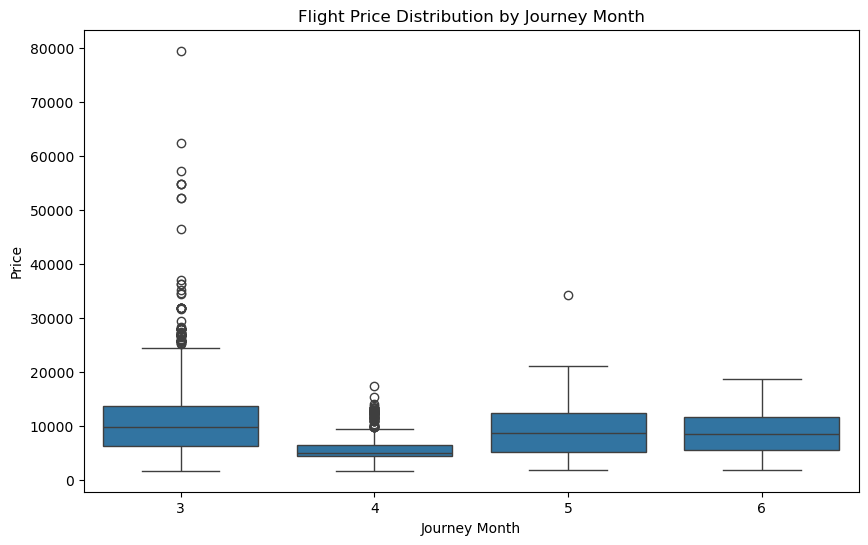

In [45]:
## Flight Price by Journey Month

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Journey_Month",
    y="Price"
)

plt.title("Flight Price Distribution by Journey Month")
plt.xlabel("Journey Month")
plt.ylabel("Price")

plt.show()

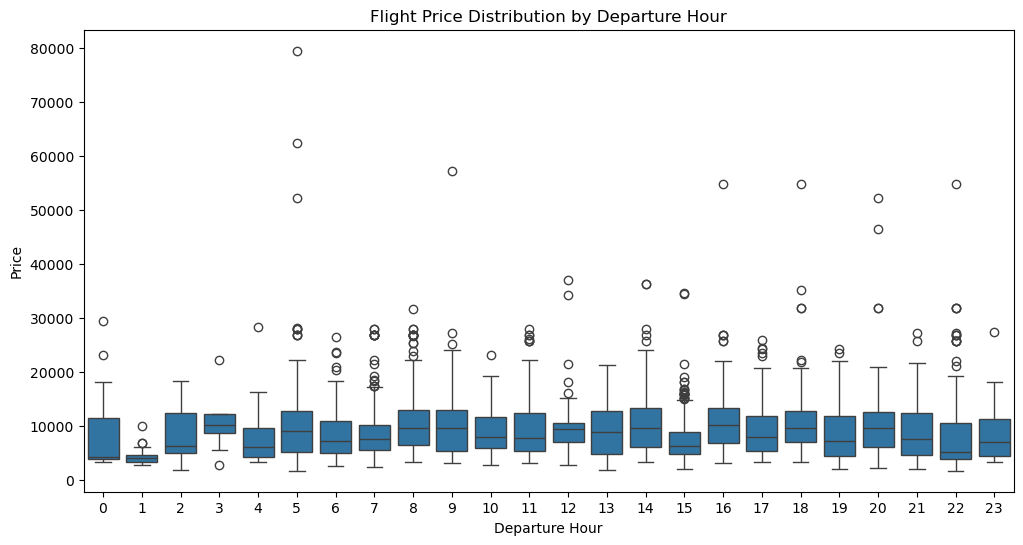

In [46]:
## Flight Price by Departure Hour

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="Dep_Hour",
    y="Price"
)

plt.title("Flight Price Distribution by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Price")

plt.show()

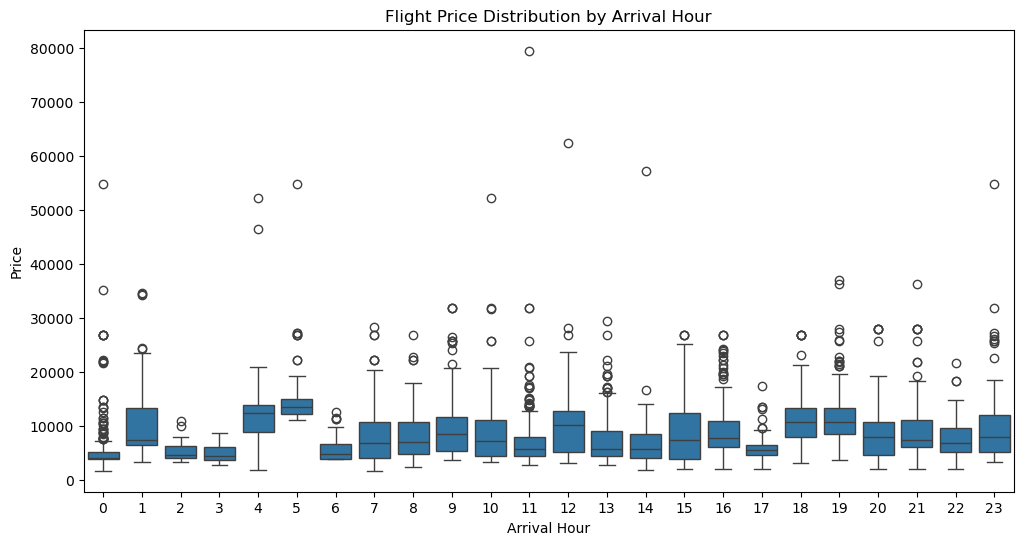

In [47]:
## 6.3 Flight Price by Arrival Hour

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="Arrival_Hour",
    y="Price"
)

plt.title("Flight Price Distribution by Arrival Hour")
plt.xlabel("Arrival Hour")
plt.ylabel("Price")

plt.show()

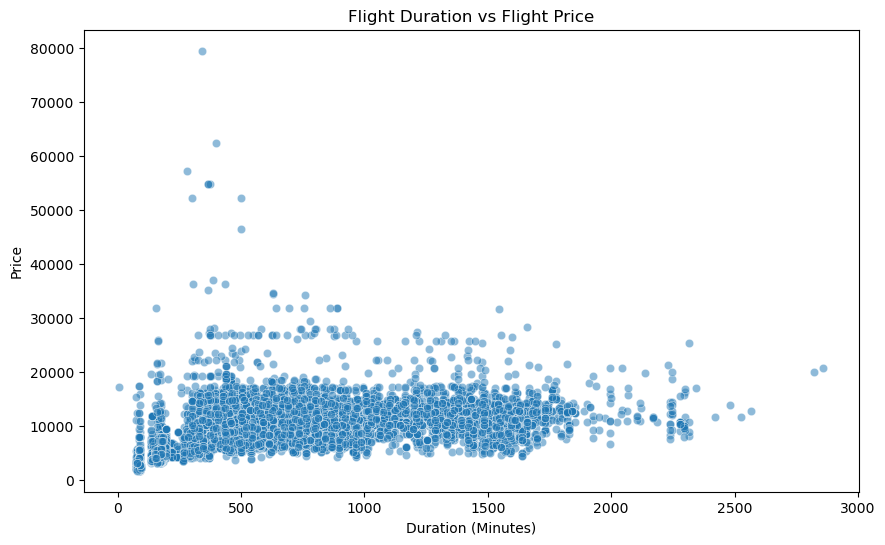

In [48]:
## Flight Duration vs Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="Duration_Minutes",
    y="Price",
    alpha=0.5
)

plt.title("Flight Duration vs Flight Price")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Price")

plt.show()

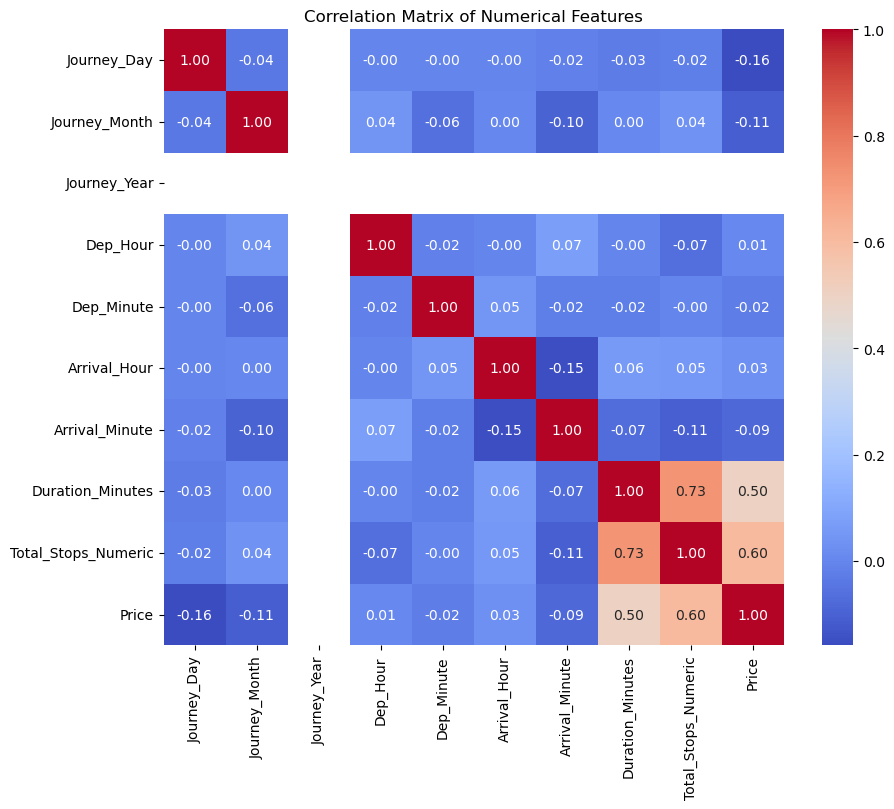

In [49]:
numeric_features = [
    "Journey_Day",
    "Journey_Month",
    "Journey_Year",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Duration_Minutes",
    "Total_Stops_Numeric",
    "Price"
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_clean[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## Machine Learning Data Preparation

In [50]:
# Check current columns

print("Dataset shape:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())

Dataset shape: (10462, 20)

Columns:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Journey_Year', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes', 'Total_Stops_Numeric']


In [51]:
# Check unique values of categorical features

categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Additional_Info"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df_clean[col].unique())


Airline:
['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']

Source:
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']

Destination:
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']

Additional_Info:
['No info' 'In-flight meal not included' 'No check-in baggage included'
 '1 Short layover' 'No Info' '1 Long layover' 'Change airports'
 'Business class' 'Red-eye flight' '2 Long layover']


In [52]:
# Check whether Journey_Year contains any useful variation

print("Unique Journey Years:")
print(df_clean["Journey_Year"].unique())

print("\nNumber of unique years:")
print(df_clean["Journey_Year"].nunique())

Unique Journey Years:
[2019]

Number of unique years:
1


In [53]:
# Check Route complexity

print("Number of unique routes:", df_clean["Route"].nunique())

print("\nMost common routes:")
print(df_clean["Route"].value_counts().head(10))

Number of unique routes: 128

Most common routes:
Route
DEL → BOM → COK    2376
BLR → DEL          1536
CCU → BOM → BLR     979
CCU → BLR           724
BOM → HYD           621
CCU → DEL → BLR     565
BLR → BOM → DEL     402
MAA → CCU           381
DEL → HYD → COK     326
DEL → BLR → COK     232
Name: count, dtype: int64


In [54]:
# Check Additional_Info distribution

print("Additional_Info value counts:")
print(df_clean["Additional_Info"].value_counts())

Additional_Info value counts:
Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64


In [55]:
# Check remaining missing values

print("Remaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [56]:
numeric_features = [
    "Journey_Day",
    "Journey_Month",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Duration_Minutes",
    "Total_Stops_Numeric"
]

In [57]:
categorical_features = [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Additional_Info"
]

In [58]:
target = "Price"

In [59]:
# Standardize Additional_Info categories

df_clean["Additional_Info"] = df_clean["Additional_Info"].str.strip()

df_clean["Additional_Info"] = df_clean["Additional_Info"].replace({
    "No Info": "No info"
})

print(df_clean["Additional_Info"].value_counts())

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64


In [60]:
# Define final features

numeric_features = [
    "Journey_Day",
    "Journey_Month",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Duration_Minutes",
    "Total_Stops_Numeric"
]

categorical_features = [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Additional_Info"
]

target = "Price"

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numeric features: ['Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes', 'Total_Stops_Numeric']
Categorical features: ['Airline', 'Source', 'Destination', 'Route', 'Additional_Info']
Target: Price


In [61]:
# Create input features (X) and target (y)

X = df_clean[numeric_features + categorical_features]
y = df_clean[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

X shape: (10462, 13)
y shape: (10462,)

First 5 rows of X:


,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Total_Stops_Numeric,Airline,Source,Destination,Route,Additional_Info
0,24,3,22,20,1,10,170,0,IndiGo,Banglore,New Delhi,BLR → DEL,No info
1,1,5,5,50,13,15,445,2,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,No info
2,9,6,9,25,4,25,1140,2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,No info
3,12,5,18,5,23,30,325,1,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,No info
4,1,3,16,50,21,35,285,1,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,No info



First 5 values of y:


0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (8369, 13)
Testing data shape: (2093, 13)
Training target shape: (8369,)
Testing target shape: (2093,)


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numeric_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [64]:
# Fit preprocessing on training data and transform both datasets

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (8369, 166)
Processed testing data shape: (2093, 166)


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [66]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models created:")
for name in models:
    print(name)

Models created:
Linear Regression
Decision Tree
Random Forest
Gradient Boosting


In [67]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_processed, y_train)
    
    trained_models[name] = model

print("\nAll models trained successfully.")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [68]:
# Evaluating Models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test_processed)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,620.769258,1424.398490,0.902691
1,Decision Tree,762.009795,1904.632853,0.826015
2,Gradient Boosting,1267.826971,1991.261015,0.809829
3,Linear Regression,1544.709453,2436.380591,0.715306


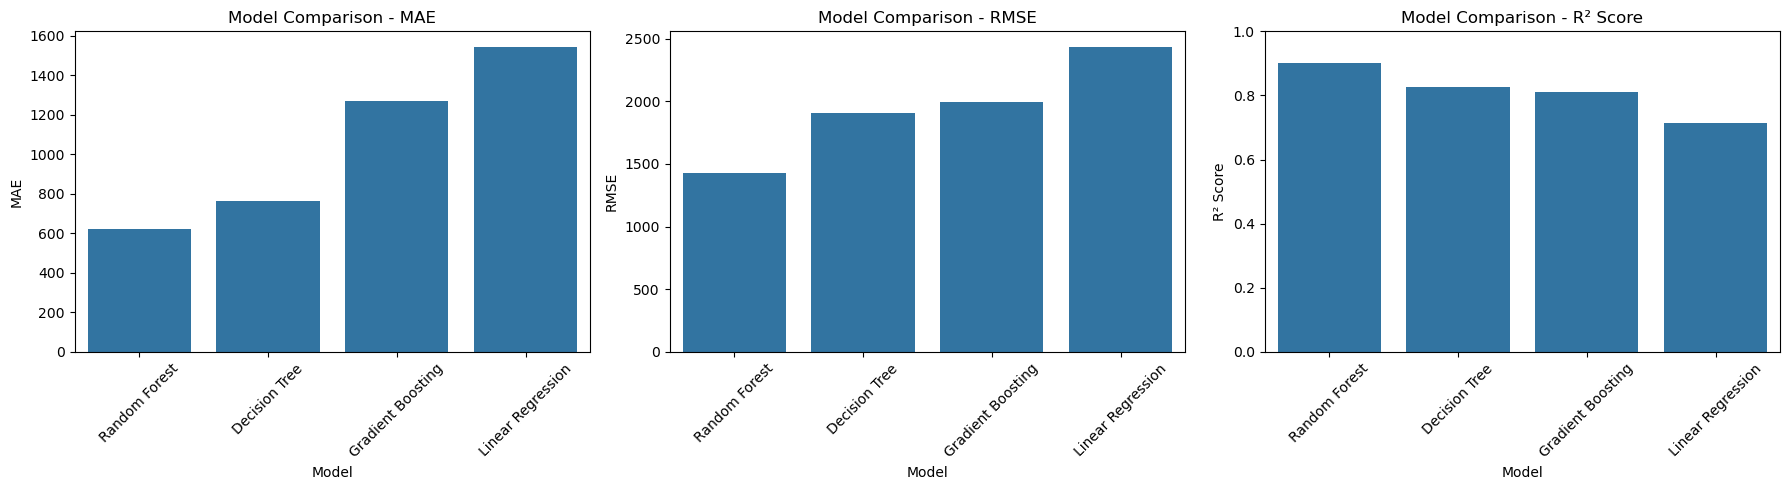

In [69]:
# Model Comparison Visualization

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0])
axes[0].set_title("Model Comparison - MAE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

# RMSE
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1])
axes[1].set_title("Model Comparison - RMSE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# R2
sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[2])
axes[2].set_title("Model Comparison - R² Score")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R² Score")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Model Comparison Report

Four regression models were trained and evaluated for flight price prediction:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

The models were evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² Score.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Random Forest | 620.77 | 1424.40 | 0.9027 |
| Decision Tree | 762.01 | 1904.63 | 0.8260 |
| Gradient Boosting | 1267.83 | 1991.26 | 0.8098 |
| Linear Regression | 1544.71 | 2436.38 | 0.7153 |

Random Forest Regressor achieved the lowest MAE and RMSE
and the highest R² Score among the evaluated models.

Therefore, Random Forest Regressor is selected as the final
candidate model for flight price prediction.

In [70]:
# Select the final model

final_model = trained_models["Random Forest"]

print("Final model selected: Random Forest Regressor")

Final model selected: Random Forest Regressor


## Final Model Prediction Analysis

The Random Forest Regressor was selected as the final candidate model based on its performance on the test dataset.

The selected model is now used to generate predictions for the unseen test data. The predicted prices are compared with the actual flight prices to understand the model's prediction performance.

In [71]:
# Generate predictions using the final Random Forest model

y_pred = final_model.predict(X_test_processed)

prediction_results = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred
})

prediction_results["Absolute_Error"] = abs(
    prediction_results["Actual_Price"] -
    prediction_results["Predicted_Price"]
)

print("Prediction results:")
display(prediction_results.head(10))

Prediction results:


,Actual_Price,Predicted_Price,Absolute_Error
0,17996,15062.535000,2933.465000
1,3873,3878.110000,5.110000
2,4462,4243.360000,218.640000
3,2228,2309.695000,81.695000
4,4991,4401.840000,589.160000
5,7670,7514.206667,155.793333
6,14086,14480.750000,394.750000
7,6386,6308.055000,77.945000
8,6628,6247.985000,380.015000
9,6934,6488.295000,445.705000


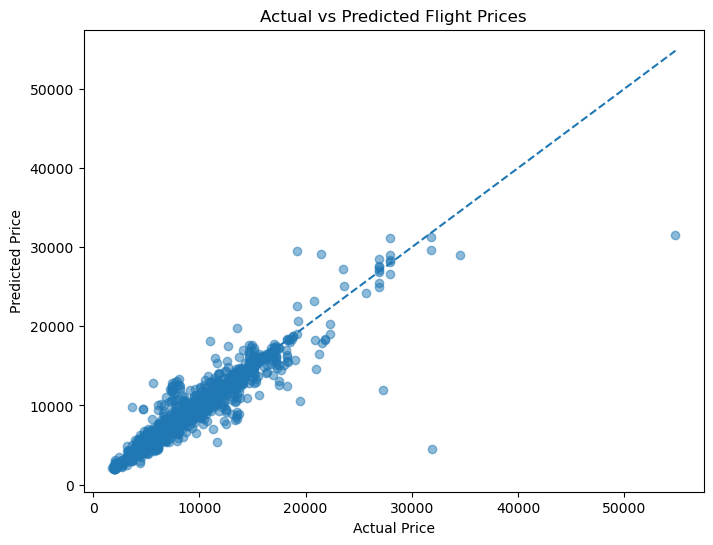

In [72]:
# Actual vs Predicted Price

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_results["Actual_Price"],
    prediction_results["Predicted_Price"],
    alpha=0.5
)

plt.plot(
    [prediction_results["Actual_Price"].min(),
     prediction_results["Actual_Price"].max()],
    [prediction_results["Actual_Price"].min(),
     prediction_results["Actual_Price"].max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

## Residual and Error Analysis

Residuals represent the difference between the actual flight price and the predicted flight price.

Residual = Actual Price − Predicted Price

Residual analysis is used to understand whether the final Random Forest model makes systematic prediction errors and to identify observations with relatively large prediction errors.

In [73]:
# Calculate residuals

prediction_results["Residual"] = (
    prediction_results["Actual_Price"] -
    prediction_results["Predicted_Price"]
)

print("Residual statistics:")
display(prediction_results["Residual"].describe())

Residual statistics:


count     2093.000000
mean       -58.018111
std       1423.556529
min     -10317.135000
25%       -337.470000
50%        -15.225000
75%        142.580000
max      27498.865000
Name: Residual, dtype: float64

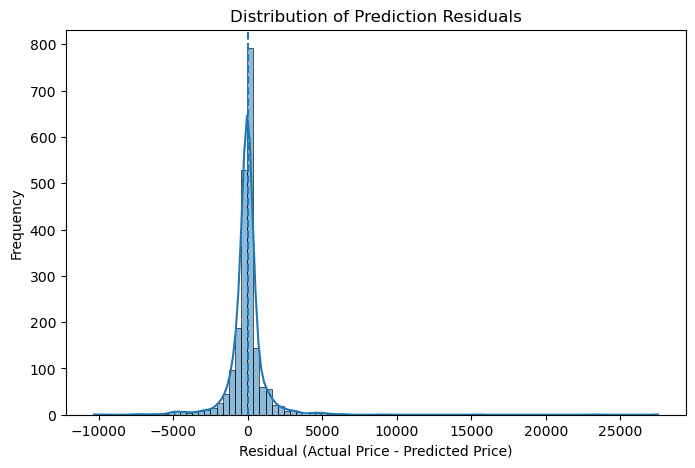

In [74]:
# Residual distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    prediction_results["Residual"],
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual (Actual Price - Predicted Price)")
plt.ylabel("Frequency")

plt.show()

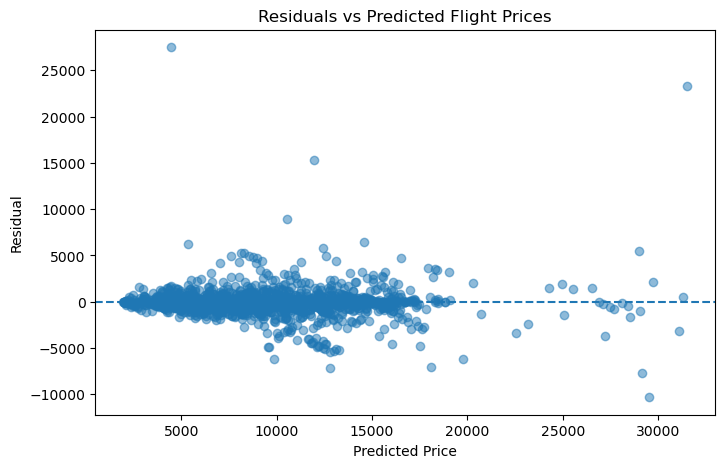

In [75]:
# Residuals vs Predicted Price

plt.figure(figsize=(8, 5))

plt.scatter(
    prediction_results["Predicted_Price"],
    prediction_results["Residual"],
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Flight Prices")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

## Challenges Faced and Solutions

During the flight price prediction project, several challenges were identified during data preparation, feature engineering, and model development.

### 1. Categorical Features

The dataset contained multiple categorical features such as Airline, Source, Destination, Route, and Additional_Info. These features could not be directly used by the regression models.

**Solution:**  
Categorical features were converted into numerical representations using one-hot encoding during preprocessing.

### 2. Additional Information Categories

The Additional_Info feature contained several categories, including "No info" and "No Info", which represented the same meaning.

**Solution:**  
The categories were standardized before encoding so that equivalent values were treated consistently.

### 3. Different Feature Scales

The numerical features had different ranges. For example, Journey Day, Departure Hour, and Duration Minutes were measured on different scales.

**Solution:**  
Numerical preprocessing was applied before model training to ensure that the features were appropriately prepared for the regression models.

### 4. Outliers in Flight Prices

The exploratory analysis showed several unusually high flight prices. These observations also contributed to larger prediction errors in the final model.

**Solution:**  
The outliers were retained because they represent actual observations in the dataset. Removing them without sufficient justification could cause the model to perform poorly on similar real-world cases.

### 5. Model Performance Differences

Different regression algorithms produced different prediction errors.

**Solution:**  
Linear Regression, Decision Tree, Random Forest, and Gradient Boosting were trained using the same training and testing datasets and compared using MAE, RMSE, and R² Score.

## Production Model Selection

Based on the evaluation results, the Random Forest Regressor was selected as the final model for flight price prediction.

The Random Forest model achieved the lowest MAE and RMSE and the highest R² Score among the four evaluated regression models.

The selected model will be used as the production candidate for generating flight price predictions.

In [76]:
# Final production model

production_model = final_model

print("Production model selected: Random Forest Regressor")
print("Model ready for final prediction use.")

Production model selected: Random Forest Regressor
Model ready for final prediction use.


# Final Conclusion

The flight price prediction project was completed by performing data analysis, data cleaning, feature engineering, exploratory data analysis, preprocessing, and machine learning model development.

Four regression models were trained and evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The Random Forest Regressor achieved the best test-set performance among the evaluated models, with an MAE of 620.77, RMSE of 1424.40, and R² Score of 0.9027. Therefore, it was selected as the final candidate model for flight price prediction.

The final model was further evaluated using actual-versus-predicted price analysis and residual analysis. Most residuals were concentrated around zero, although some observations showed relatively large prediction errors.

The project demonstrates how machine learning can be applied to predict flight prices using factors such as airline, source, destination, journey date, departure and arrival times, flight duration, route, and number of stops.

Overall, the Random Forest Regressor was selected as the final candidate model based on its performance on the test dataset.